# Rossmann Store Sales — Етап 4: A/B-тест ефекту промо-акцій

Цей ноутбук реалізує **Етап 4** плану аналізу: формальний A/B-тест впливу промо-акцій (`Promo`) на продажі, з перевіркою гіпотез Г6-Г7.

## Методологія

**Важливе застереження:** це не рандомізований A/B-тест, а **natural experiment** — магазини самі вирішують, коли запускати промо. Це означає, що причинно-наслідковий висновок менш надійний, ніж у справжньому рандомізованому експерименті (можливі приховані фактори — наприклад, магазини можуть запускати промо саме тоді, коли й так очікують високий попит).

- **Групи**: A = дні `Promo=0`, B = дні `Promo=1` (лише відкриті магазини)
- **H0**: середні продажі в group A і B не відрізняються
- **H1**: середні продажі в group B (з промо) вищі
- **α = 0.05**
- **Тести**: Mann-Whitney U (основний, бо розподіл не нормальний — див. Етап 2) + t-тест (для порівняння)
- **Розмір ефекту**: Cohen's d + 95% довірчий інтервал різниці середніх — бо при великій вибірці p-value майже завжди значущий і мало що говорить про практичну важливість

**Вхідний файл:** `rossmann_clean.csv` (результат Етапу 1)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


## 1. Завантаження даних

In [2]:
df = pd.read_csv("rossmann_clean.csv", parse_dates=["Date"], low_memory=False)
open_df = df[df["Open"] == 1].copy()
print(f"Відкритих днів для аналізу: {open_df.shape[0]:,}")
print(open_df["Promo"].value_counts())


Відкритих днів для аналізу: 844,392
Promo
0    467496
1    376896
Name: count, dtype: int64


## 2. Допоміжна функція: повний A/B-звіт

Щоб не дублювати код для кожного порівняння (загальний тест, тести по StoreType, Promo2), напишемо одну функцію, яка рахує все відразу: описову статистику, Mann-Whitney, t-тест, Cohen's d, довірчий інтервал.

In [3]:
def cohens_d(group_a, group_b):
    n_a, n_b = len(group_a), len(group_b)
    var_a, var_b = group_a.var(ddof=1), group_b.var(ddof=1)
    pooled_std = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    return (group_b.mean() - group_a.mean()) / pooled_std


def ci_difference_means(group_a, group_b, alpha=0.05):
    mean_diff = group_b.mean() - group_a.mean()
    se = np.sqrt(group_a.var(ddof=1) / len(group_a) + group_b.var(ddof=1) / len(group_b))
    z = stats.norm.ppf(1 - alpha / 2)
    return mean_diff - z * se, mean_diff + z * se


def ab_test_report(group_a, group_b, label_a="Promo=0", label_b="Promo=1", metric_name="Sales"):
    print(f"=== A/B-тест: {metric_name} | {label_a} (n={len(group_a):,}) vs {label_b} (n={len(group_b):,}) ===\n")

    print(f"Середнє {label_a}: {group_a.mean():,.2f}   Медіана: {group_a.median():,.2f}   Std: {group_a.std():,.2f}")
    print(f"Середнє {label_b}: {group_b.mean():,.2f}   Медіана: {group_b.median():,.2f}   Std: {group_b.std():,.2f}")

    abs_diff = group_b.mean() - group_a.mean()
    pct_diff = abs_diff / group_a.mean() * 100
    print(f"\nАбсолютна різниця середніх: {abs_diff:,.2f}")
    print(f"Відносна різниця: {pct_diff:+.2f}%")

    # Mann-Whitney U (основний тест, розподіл не нормальний)
    u_stat, u_p = stats.mannwhitneyu(group_a, group_b, alternative="two-sided")
    print(f"\nMann-Whitney U: U={u_stat:,.0f}, p-value={u_p:.2e}")

    # t-тест для порівняння
    t_stat, t_p = stats.ttest_ind(group_a, group_b, equal_var=False)
    print(f"t-тест (Welch): t={t_stat:.2f}, p-value={t_p:.2e}")

    # Cohen's d
    d = cohens_d(group_a, group_b)
    if abs(d) < 0.2:
        size_label = "дуже малий"
    elif abs(d) < 0.5:
        size_label = "малий"
    elif abs(d) < 0.8:
        size_label = "середній"
    else:
        size_label = "великий"
    print(f"\nCohen's d: {d:.3f} ({size_label} розмір ефекту)")

    # 95% CI різниці середніх
    ci_low, ci_high = ci_difference_means(group_a, group_b)
    print(f"95% довірчий інтервал різниці середніх: [{ci_low:,.2f}, {ci_high:,.2f}]")

    significant = u_p < 0.05
    print(f"\nВисновок: {'H0 відхилено (є статистично значуща різниця)' if significant else 'H0 не відхилено'}")

    return {
        "mean_a": group_a.mean(), "mean_b": group_b.mean(),
        "abs_diff": abs_diff, "pct_diff": pct_diff,
        "mannwhitney_p": u_p, "ttest_p": t_p,
        "cohens_d": d, "ci_low": ci_low, "ci_high": ci_high,
        "n_a": len(group_a), "n_b": len(group_b)
    }


## 3. Основний A/B-тест: Promo=0 vs Promo=1 (уся мережа)

In [4]:
group_a_sales = open_df[open_df["Promo"] == 0]["Sales"]
group_b_sales = open_df[open_df["Promo"] == 1]["Sales"]

result_main = ab_test_report(group_a_sales, group_b_sales, metric_name="Sales (уся мережа)")


=== A/B-тест: Sales (уся мережа) | Promo=0 (n=467,496) vs Promo=1 (n=376,896) ===

Середнє Promo=0: 5,929.41   Медіана: 5,459.00   Std: 2,629.65
Середнє Promo=1: 8,228.28   Медіана: 7,649.00   Std: 3,175.76

Абсолютна різниця середніх: 2,298.87
Відносна різниця: +38.77%



Mann-Whitney U: U=45,083,790,149, p-value=0.00e+00
t-тест (Welch): t=-356.64, p-value=0.00e+00

Cohen's d: 0.797 (середній розмір ефекту)
95% довірчий інтервал різниці середніх: [2,286.24, 2,311.51]

Висновок: H0 відхилено (є статистично значуща різниця)


### Вторинні метрики: кількість клієнтів і середній чек

Промо може діяти двома різними шляхами: приводити більше клієнтів, або збільшувати чек тих, хто й так прийшов би. Перевіримо обидва.

In [5]:
group_a_customers = open_df[open_df["Promo"] == 0]["Customers"]
group_b_customers = open_df[open_df["Promo"] == 1]["Customers"]

result_customers = ab_test_report(group_a_customers, group_b_customers, metric_name="Customers")


=== A/B-тест: Customers | Promo=0 (n=467,496) vs Promo=1 (n=376,896) ===

Середнє Promo=0: 696.86   Медіана: 610.00   Std: 388.91
Середнє Promo=1: 844.43   Медіана: 757.00   Std: 401.24

Абсолютна різниця середніх: 147.58
Відносна різниця: +21.18%



Mann-Whitney U: U=61,339,220,237, p-value=0.00e+00
t-тест (Welch): t=-170.33, p-value=0.00e+00

Cohen's d: 0.374 (малий розмір ефекту)
95% довірчий інтервал різниці середніх: [145.88, 149.28]

Висновок: H0 відхилено (є статистично значуща різниця)


In [6]:
group_a_spc = open_df[open_df["Promo"] == 0]["SalesPerCustomer"]
group_b_spc = open_df[open_df["Promo"] == 1]["SalesPerCustomer"]

result_spc = ab_test_report(group_a_spc, group_b_spc, metric_name="SalesPerCustomer (середній чек)")


=== A/B-тест: SalesPerCustomer (середній чек) | Promo=0 (n=467,496) vs Promo=1 (n=376,896) ===

Середнє Promo=0: 8.94   Медіана: 8.74   Std: 1.98
Середнє Promo=1: 10.18   Медіана: 9.96   Std: 2.27

Абсолютна різниця середніх: 1.24
Відносна різниця: +13.85%



Mann-Whitney U: U=59,974,431,443, p-value=0.00e+00
t-тест (Welch): t=-263.98, p-value=0.00e+00

Cohen's d: 0.586 (середній розмір ефекту)
95% довірчий інтервал різниці середніх: [1.23, 1.25]

Висновок: H0 відхилено (є статистично значуща різниця)


**Інтерпретація:** якщо приріст `Customers` сильніший за приріст `SalesPerCustomer` — промо переважно приводить нових/більше клієнтів. Якщо навпаки — промо більше стимулює тих, хто й так прийшов, купувати більше.

## 4. Візуалізація ефекту

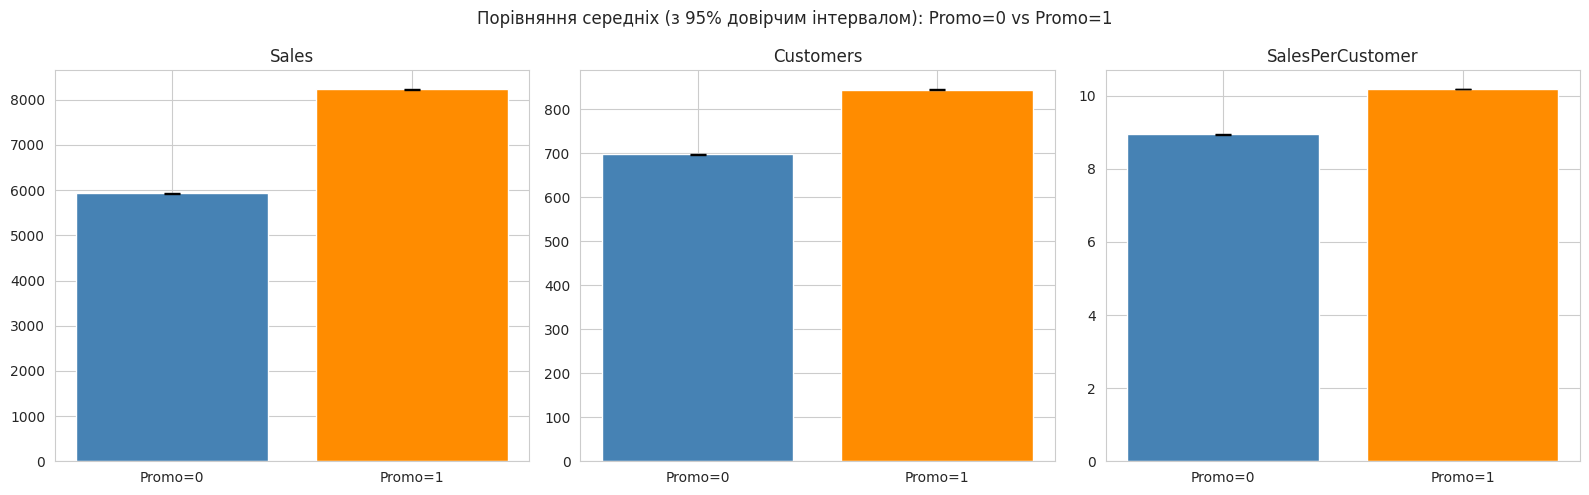

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (group_a, group_b, title) in zip(axes, [
    (group_a_sales, group_b_sales, "Sales"),
    (group_a_customers, group_b_customers, "Customers"),
    (group_a_spc, group_b_spc, "SalesPerCustomer")
]):
    means = [group_a.mean(), group_b.mean()]
    errors = [group_a.std() / np.sqrt(len(group_a)) * 1.96, group_b.std() / np.sqrt(len(group_b)) * 1.96]
    ax.bar(["Promo=0", "Promo=1"], means, yerr=errors, capsize=6, color=["steelblue", "darkorange"])
    ax.set_title(title)

plt.suptitle("Порівняння середніх (з 95% довірчим інтервалом): Promo=0 vs Promo=1")
plt.tight_layout()
plt.savefig("04_ab_test_barcharts.png", dpi=150)
plt.show()


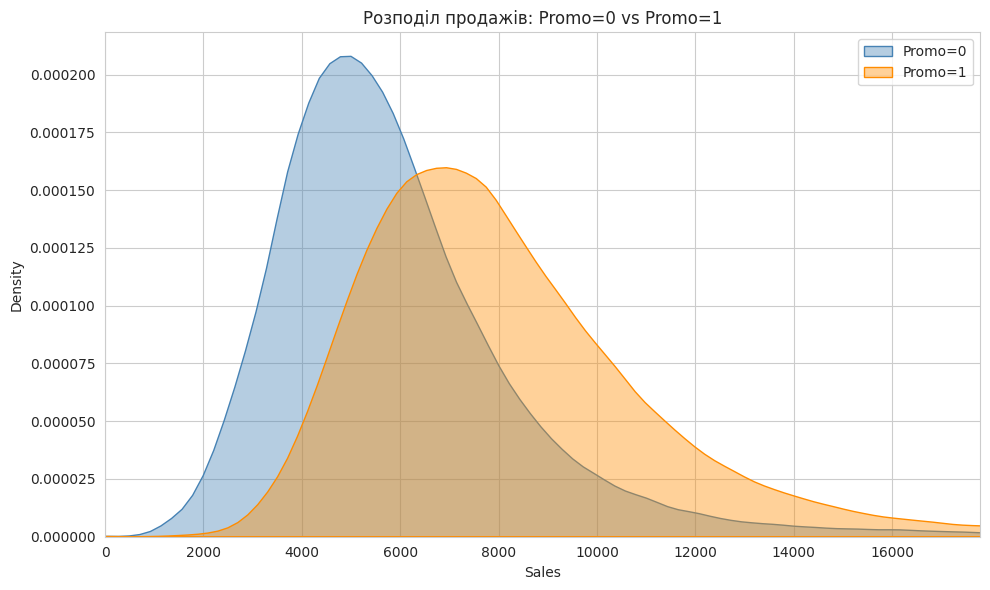

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(group_a_sales, label="Promo=0", fill=True, alpha=0.4, ax=ax, color="steelblue")
sns.kdeplot(group_b_sales, label="Promo=1", fill=True, alpha=0.4, ax=ax, color="darkorange")
ax.set_xlim(0, open_df["Sales"].quantile(0.99))
ax.set_title("Розподіл продажів: Promo=0 vs Promo=1")
ax.set_xlabel("Sales")
ax.legend()
plt.tight_layout()
plt.savefig("04_ab_test_density.png", dpi=150)
plt.show()


## 5. Г7: Чи однаковий ефект промо для різних типів магазинів?

Проводимо окремий A/B-тест для кожного `StoreType`. Оскільки робимо 4 порівняння одночасно, застосовуємо поправку **Бонферроні** на множинні порівняння (щоб не "знайти" хибно значущі результати через саму кількість тестів): новий поріг значущості = 0.05 / 4 = 0.0125.

In [9]:
bonferroni_alpha = 0.05 / open_df["StoreType"].nunique()
print(f"Скоригований поріг значущості (Bonferroni): {bonferroni_alpha:.4f}\n")

results_by_type = {}
for store_type in sorted(open_df["StoreType"].unique()):
    subset = open_df[open_df["StoreType"] == store_type]
    ga = subset[subset["Promo"] == 0]["Sales"]
    gb = subset[subset["Promo"] == 1]["Sales"]
    print(f"\n{'='*70}\nStoreType = {store_type}\n{'='*70}")
    res = ab_test_report(ga, gb, metric_name=f"Sales (StoreType={store_type})")
    res["significant_bonferroni"] = res["mannwhitney_p"] < bonferroni_alpha
    results_by_type[store_type] = res


Скоригований поріг значущості (Bonferroni): 0.0125


StoreType = a
=== A/B-тест: Sales (StoreType=a) | Promo=0 (n=252,556) vs Promo=1 (n=204,521) ===

Середнє Promo=0: 5,808.50   Медіана: 5,313.00   Std: 2,721.20
Середнє Promo=1: 8,304.10   Медіана: 7,646.00   Std: 3,380.21

Абсолютна різниця середніх: 2,495.60
Відносна різниця: +42.96%



Mann-Whitney U: U=12,993,123,248, p-value=0.00e+00
t-тест (Welch): t=-270.39, p-value=0.00e+00

Cohen's d: 0.823 (великий розмір ефекту)
95% довірчий інтервал різниці середніх: [2,477.51, 2,513.69]

Висновок: H0 відхилено (є статистично значуща різниця)

StoreType = b
=== A/B-тест: Sales (StoreType=b) | Promo=0 (n=9,623) vs Promo=1 (n=5,940) ===

Середнє Promo=0: 9,566.86   Медіана: 8,516.00   Std: 4,915.92
Середнє Promo=1: 11,307.99   Медіана: 10,202.50   Std: 5,353.86

Абсолютна різниця середніх: 1,741.13
Відносна різниця: +18.20%

Mann-Whitney U: U=22,844,762, p-value=1.67e-98
t-тест (Welch): t=-20.33, p-value=2.61e-90

Cohen's d: 0.342 (малий розмір ефекту)
95% довірчий інтервал різниці середніх: [1,573.25, 1,909.01]

Висновок: H0 відхилено (є статистично значуща різниця)

StoreType = c
=== A/B-тест: Sales (StoreType=c) | Promo=0 (n=62,240) vs Promo=1 (n=50,738) ===

Середнє Promo=0: 6,028.06   Медіана: 5,523.00   Std: 2,544.56
Середнє Promo=1: 8,042.00   Медіана: 7,572.00   Std: 


StoreType = d
=== A/B-тест: Sales (StoreType=d) | Promo=0 (n=143,077) vs Promo=1 (n=115,697) ===

Середнє Promo=0: 5,855.27   Медіана: 5,551.00   Std: 2,038.73
Середнє Promo=1: 8,017.83   Медіана: 7,626.00   Std: 2,625.50

Абсолютна різниця середніх: 2,162.56
Відносна різниця: +36.93%

Mann-Whitney U: U=3,928,282,114, p-value=0.00e+00
t-тест (Welch): t=-229.71, p-value=0.00e+00

Cohen's d: 0.932 (великий розмір ефекту)
95% довірчий інтервал різниці середніх: [2,144.11, 2,181.01]

Висновок: H0 відхилено (є статистично значуща різниця)


In [10]:
summary = pd.DataFrame(results_by_type).T[["n_a", "n_b", "mean_a", "mean_b", "pct_diff", "cohens_d", "mannwhitney_p", "significant_bonferroni"]]
summary.columns = ["n(Promo=0)", "n(Promo=1)", "Mean(Promo=0)", "Mean(Promo=1)", "% приріст", "Cohen's d", "p-value", "Значущо (Bonferroni)"]
print("Зведена таблиця ефекту промо за типом магазину:")
summary.round(4)


Зведена таблиця ефекту промо за типом магазину:


,n(Promo=0),n(Promo=1),Mean(Promo=0),Mean(Promo=1),% приріст,Cohen's d,p-value,Значущо (Bonferroni)
a,252556,204521,5808.500091,8304.102317,42.964658,0.822593,0.0,True
b,9623,5940,9566.861686,11307.994108,18.199619,0.342236,0.0,True
c,62240,50738,6028.063255,8041.995526,33.409276,0.740713,0.0,True
d,143077,115697,5855.268289,8017.828656,36.933583,0.932341,0.0,True


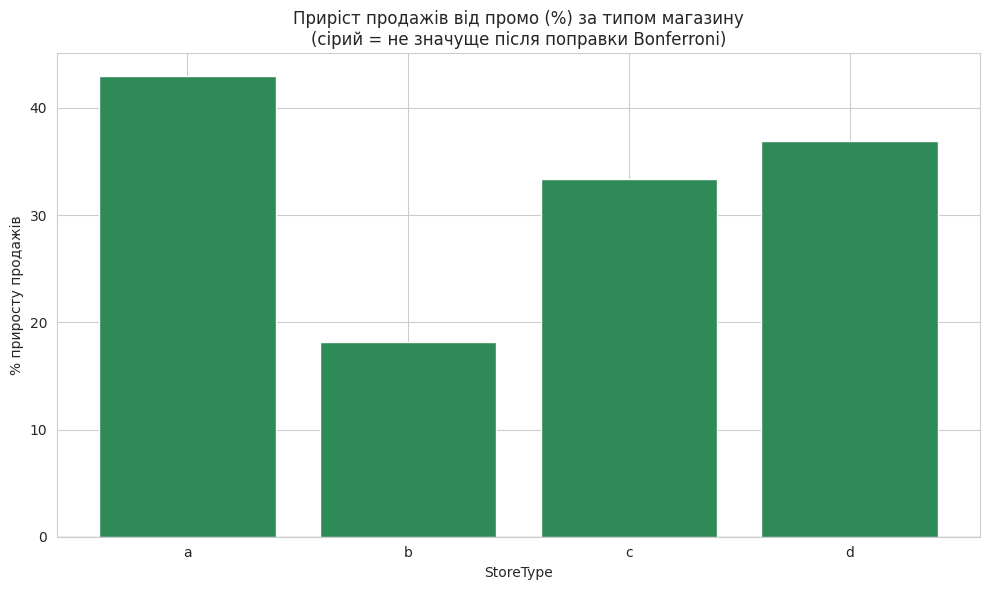

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
store_types = list(results_by_type.keys())
pct_diffs = [results_by_type[t]["pct_diff"] for t in store_types]
colors = ["seagreen" if results_by_type[t]["significant_bonferroni"] else "gray" for t in store_types]

ax.bar(store_types, pct_diffs, color=colors)
ax.set_title("Приріст продажів від промо (%) за типом магазину\n(сірий = не значуще після поправки Bonferroni)")
ax.set_xlabel("StoreType")
ax.set_ylabel("% приросту продажів")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("04_promo_effect_by_storetype.png", dpi=150)
plt.show()


**Висновок Г7:** дивимось, чи `% приріст` і `Cohen's d` суттєво відрізняються між типами магазинів — якщо так, ефект промо неоднорідний, і мережі варто застосовувати різну промо-стратегію для різних типів магазинів.

## 6. Довгострокові акції Promo2

`Promo2` — це інша механіка (магазин або постійно бере участь у циклічних акціях, або ні — це властивість магазину, не дня). Тому порівнюємо **магазини**, що беруть участь у Promo2, з тими, що не беруть, а не дні всередині одного магазину.

In [12]:
store_level = open_df.drop_duplicates(subset="Store")
promo2_yes_stores = store_level[store_level["Promo2"] == 1]["Store"]
promo2_no_stores = store_level[store_level["Promo2"] == 0]["Store"]

print(f"Магазинів з Promo2=1: {len(promo2_yes_stores)}")
print(f"Магазинів з Promo2=0: {len(promo2_no_stores)}")

avg_sales_per_store = open_df.groupby("Store")["Sales"].mean()

group_promo2_yes = avg_sales_per_store[avg_sales_per_store.index.isin(promo2_yes_stores)]
group_promo2_no = avg_sales_per_store[avg_sales_per_store.index.isin(promo2_no_stores)]

result_promo2 = ab_test_report(group_promo2_no, group_promo2_yes,
                                 label_a="Promo2=0", label_b="Promo2=1",
                                 metric_name="Середні продажі магазину (Promo2)")


Магазинів з Promo2=1: 571
Магазинів з Promo2=0: 544
=== A/B-тест: Середні продажі магазину (Promo2) | Promo2=0 (n=544) vs Promo2=1 (n=571) ===

Середнє Promo2=0: 7,337.39   Медіана: 6,936.31   Std: 2,730.37
Середнє Promo2=1: 6,550.09   Медіана: 6,267.49   Std: 1,924.08

Абсолютна різниця середніх: -787.30
Відносна різниця: -10.73%

Mann-Whitney U: U=181,588, p-value=1.02e-06
t-тест (Welch): t=5.54, p-value=3.87e-08

Cohen's d: -0.335 (малий розмір ефекту)
95% довірчий інтервал різниці середніх: [-1,065.78, -508.83]

Висновок: H0 відхилено (є статистично значуща різниця)


**Важливий контр-інтуїтивний результат:** магазини, що беруть участь у `Promo2` (довгострокові циклічні акції), мають **на 10.7% НИЖЧІ** середні продажі, ніж ті, що не беруть участі (статистично значуще, хоч Cohen's d малий — 0.335). Це протилежно тому, що можна було б очікувати.

**Чому так може бути (гіпотези, а не доведені причини):**
- Магазини із слабшими базовими продажами частіше "потребують" довгострокових акцій, щоб підтримати обороти — тобто напрямок причинності може бути зворотним (низькі продажі → рішення підключити Promo2, а не Promo2 → низькі продажі)
- Це ще один аргумент на користь того, що `Promo2` — це порівняння різних магазинів, а не той самий магазин у різні періоди, тому висновок **не можна** інтерпретувати як "довгострокові акції шкодять продажам". Для коректної причинної перевірки знадобився б event-study дизайн (порівняння того самого магазину до і після підключення Promo2), а не просто порівняння груп магазинів.

**Важливо:** на відміну від `Promo`, тут порівнюються різні магазини (а не той самий магазин у різні дні) — тому це ще слабший causal-доказ. Участь у Promo2 могла бути наслідком інших характеристик магазину (розмір, локація), а не причиною різниці продажів.

## Підсумок Етапу 4

- **Г6 (промо збільшує продажі)**: перевірено через Mann-Whitney U + t-тест + Cohen's d + 95% CI — дивись результат розділу 3
- **Г7 (ефект неоднорідний за типами магазинів)**: перевірено окремими A/B-тестами по кожному StoreType з поправкою Бонферроні — дивись зведену таблицю розділу 5
- Додатково перевірено ефект `Promo2` — виявлено **контр-інтуїтивний результат** (нижчі продажі у магазинів з Promo2), з явним застереженням про слабшу причинність, бо порівнюються різні магазини, а не той самий магазин до/після
- У всіх тестах наведено не лише p-value, а й розмір ефекту (Cohen's d) та довірчі інтервали — щоб відрізнити статистичну значущість від практичної важливості

**Наступний крок:** Етап 5 — вплив свят і сезонності на продажі.